
# 06 · Results summary

Reads every results file in `runs/` and compiles them into one table with box plots and comparisons.
Re-run after any new training run.

### Reported

- MAE and RMSE in the target's own units, and pooled R² over all held-out recordings
- Mean and standard deviation across seeds, which is the error bar for comparing architectures
- Box plots of per-fold MAE and RMSE, pooled across seeds
- Paired Wilcoxon tests between architectures on identical folds
- Permutation nulls, if any runs were made with `PERMUTE = True`

### Interpretation

Targets sit close to zero with wide per-fold spreads. Treat a difference between architectures as
meaningful only if it exceeds the seed-to-seed standard deviation and clears the permutation null.
Fix one target as the primary endpoint before comparing.

In [1]:

# !pip install -q numpy pandas matplotlib scipy

In [2]:

import os, json, glob, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

BASE = f"/scratch/{os.environ.get('USER','username')}/capstone"
RUNS    = os.path.join(BASE, "runs")
FIG_DIR = os.path.join(BASE, "figures", "results"); os.makedirs(FIG_DIR, exist_ok=True)
print("reading:", os.path.relpath(RUNS, BASE) + "/")

reading: runs/



**Load every results file.** Tolerant of older JSON shapes — missing fields come through as `NaN`.
Runs that stored `mse` instead of `rmse` are converted, so an older sweep still lines up.

In [3]:

def pick(d, *names):
    for n in names:
        if isinstance(d, dict) and d.get(n) is not None:
            return d[n]
    return None

def get_rmse(block):
    """RMSE, converting from MSE if a run recorded that instead."""
    r = pick(block, "rmse")
    if r is not None: return float(r)
    m = pick(block, "mse")
    return float(np.sqrt(m)) if m is not None else np.nan

rows, folds_long, raw = [], [], {}
for fp in sorted(glob.glob(os.path.join(RUNS, "*_results.json"))):
    try:
        d = json.load(open(fp))
    except Exception as e:
        print("skip", os.path.basename(fp), e); continue
    raw[os.path.basename(fp)] = d

    head  = pick(d, "headline") or pick(d, "rec") or {}
    bmean = pick(d, "baseline") or pick(d, "rec_base") or {}
    bmed  = pick(d, "baseline_median") or {}
    model, target = pick(d, "model") or "?", pick(d, "target") or "?"
    seed, perm    = pick(d, "seed"), bool(pick(d, "permuted") or False)

    pf = pick(d, "per_fold") or []
    pf_mae  = np.array([pick(x,"mae") for x in pf if pick(x,"mae") is not None], float)
    pf_rmse = np.array([get_rmse(x) for x in pf], float) if pf else np.array([])
    pf_r2   = np.array([pick(x,"r2") for x in pf if pick(x,"r2") is not None], float)

    for i, x in enumerate(pf):
        folds_long.append(dict(model=model, target=target, seed=seed, fold=i, permuted=perm,
                               family=pick(d,"family"), config=pick(d,"config_name"),
                               mae=pick(x,"mae"), rmse=get_rmse(x), r2=pick(x,"r2")))

    stops   = pick(d, "stops") or []
    n_early = sum(1 for s in stops if s.get("early_stopped"))
    eps     = [s.get("epochs_run") for s in stops if s.get("epochs_run") is not None]
    bests   = [s.get("best_epoch")  for s in stops if s.get("best_epoch")  is not None]

    mae  = pick(head, "mae")
    b_mu = pick(bmean, "mae"); b_md = pick(bmed, "mae")
    cands = [v for v in (b_mu, b_md) if v is not None]
    hard  = min(cands) if cands else np.nan

    rows.append(dict(
        model=model, family=pick(d,"family"), target=target,
        config=pick(d,"config_name") or "unknown", n_params=pick(d,"n_params"),
        seed=seed, permuted=perm,
        MAE=mae, RMSE=get_rmse(head), R2=pick(head,"r2"),
        MAE_mean_base=b_mu, MAE_median_base=b_md, RMSE_base=get_rmse(bmean),
        MAE_fold_mean=(np.nanmean(pf_mae) if len(pf_mae) else np.nan),
        MAE_fold_sd=(np.nanstd(pf_mae) if len(pf_mae) > 1 else np.nan),
        RMSE_fold_mean=(np.nanmean(pf_rmse) if len(pf_rmse) else np.nan),
        RMSE_fold_sd=(np.nanstd(pf_rmse) if len(pf_rmse) > 1 else np.nan),
        # nan-safe: folds with an undefined R2 are ignored rather than propagated
        R2_fold_mean=(np.nanmean(pf_r2) if np.any(np.isfinite(pf_r2)) else np.nan),
        R2_fold_median=(np.nanmedian(pf_r2) if np.any(np.isfinite(pf_r2)) else np.nan),
        R2_fold_sd=(np.nanstd(pf_r2) if np.sum(np.isfinite(pf_r2)) > 1 else np.nan),
        folds=len(stops) or (len(pf) or np.nan),
        early_stopped=n_early if stops else np.nan,
        median_epochs=(int(np.median(eps)) if eps else np.nan),
        median_best_epoch=(int(np.median(bests)) if bests else np.nan),
        beats_base=(mae is not None and np.isfinite(hard) and mae < hard),
        minutes=pick(d,"minutes"), file=os.path.basename(fp)))

allruns = pd.DataFrame(rows)
if allruns.empty:
    raise SystemExit(f"No *_results.json in {RUNS}. Run notebooks 03 and 04 first.")
allruns["MAE_vs_base"] = allruns["MAE"] / allruns[["MAE_mean_base","MAE_median_base"]].min(axis=1)

FL   = pd.DataFrame(folds_long)
null = allruns[allruns["permuted"]].copy()
df   = allruns[~allruns["permuted"]].copy().sort_values(
           ["target","family","model","seed"]).reset_index(drop=True)
FLr  = FL[~FL["permuted"]].copy()

targets = sorted(df["target"].unique())
models  = list(df.groupby("model")["n_params"].first().sort_values().index)
print(f"{len(df)} real run(s) | {len(null)} permuted | models: {models} | "
      f"seeds: {sorted(df['seed'].dropna().unique())}\n")
show = ["model","family","target","n_params","seed","MAE","RMSE","R2",
        "MAE_mean_base","MAE_median_base","MAE_fold_mean","MAE_fold_sd","beats_base"]
with pd.option_context("display.float_format", lambda v: f"{v:.4g}", "display.width", 250):
    print(df[show].to_string(index=False))
allruns.to_csv(os.path.join(RUNS, "summary.csv"), index=False)
print("\nsaved ->", os.path.join(RUNS, "summary.csv"))

50 real run(s) | 0 permuted | models: ['cnn', 'bigru', 'densenet', 'resnet', 'bilstm'] | seeds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

   model   family                  target  n_params  seed    MAE   RMSE       R2  MAE_mean_base  MAE_median_base  MAE_fold_mean  MAE_fold_sd  beats_base
     cnn    image richness_rare_no_anchoa     40161     0  2.125  2.789  -0.0311          2.174            2.154          2.129        0.201        True
     cnn    image richness_rare_no_anchoa     40161     1  2.116   2.71  0.02674           2.15            2.173          2.128       0.3689        True
     cnn    image richness_rare_no_anchoa     40161     2  2.082  2.706   0.0293          2.142            2.173          2.076       0.5444        True
     cnn    image richness_rare_no_anchoa     40161     3  2.081  2.736 0.007924          2.163            2.187          2.086       0.3227        True
     cnn    image richness_rare_no_anchoa     40161     4  2.139  2.798 


**Headline table: mean ± seed-to-seed sd.** This is the table for the report. The sd here is across
seeds, not folds — it answers "how much would this number move if I reran it," which is the relevant
uncertainty when ranking architectures.

In [4]:

g = df.groupby(["target","model"]).agg(
        family=("family","first"), params=("n_params","first"), n_seeds=("seed","count"),
        MAE=("MAE","mean"),   MAE_sd=("MAE","std"),
        RMSE=("RMSE","mean"), RMSE_sd=("RMSE","std"),
        R2=("R2","mean"),     R2_sd=("R2","std"),
        MAE_base=("MAE_median_base","first")).reset_index()
g["MAE_vs_base"] = g["MAE"] / g["MAE_base"]
g = g.sort_values(["target","R2"], ascending=[True, False]).reset_index(drop=True)
with pd.option_context("display.float_format", lambda v: f"{v:.4f}", "display.width", 250):
    print(g.to_string(index=False))

print("\nformatted for the report:")
for tgt in targets:
    print(f"\n{tgt}")
    for _, r in g[g["target"]==tgt].iterrows():
        print(f"  {r['model']:10s} ({int(r['params']):>7,d} params)  "
              f"R² {r['R2']:+.3f} ± {r['R2_sd']:.3f}   "
              f"MAE {r['MAE']:.4f} ± {r['MAE_sd']:.4f}   "
              f"RMSE {r['RMSE']:.4f} ± {r['RMSE_sd']:.4f}")

                 target    model   family  params  n_seeds    MAE  MAE_sd   RMSE  RMSE_sd      R2  R2_sd  MAE_base  MAE_vs_base
richness_rare_no_anchoa    bigru sequence  174978        5 1.9548  0.0757 2.5749   0.1106  0.1200 0.0759    2.1537       0.9076
richness_rare_no_anchoa   bilstm sequence  224898        5 2.0096  0.0531 2.6266   0.1246  0.0840 0.0869    2.1537       0.9331
richness_rare_no_anchoa   resnet    image  191601        5 2.1169  0.0502 2.7234   0.0786  0.0164 0.0571    2.1537       0.9829
richness_rare_no_anchoa      cnn    image   40161        5 2.1087  0.0263 2.7479   0.0434 -0.0009 0.0317    2.1537       0.9791
richness_rare_no_anchoa densenet    image  178045        5 2.1477  0.0593 2.7819   0.1070 -0.0268 0.0781    2.1537       0.9972
 shannon_rare_no_anchoa   bilstm sequence  224898        5 0.2695  0.0130 0.3347   0.0140  0.1882 0.0694    0.3073       0.8768
 shannon_rare_no_anchoa    bigru sequence  174978        5 0.2744  0.0113 0.3382   0.0101  0.1717 0.0498


**Box plots — per-fold MAE.** Every fold of every seed, so 25 values per architecture. The dashed
line is the median baseline; boxes below it are doing better than guessing.

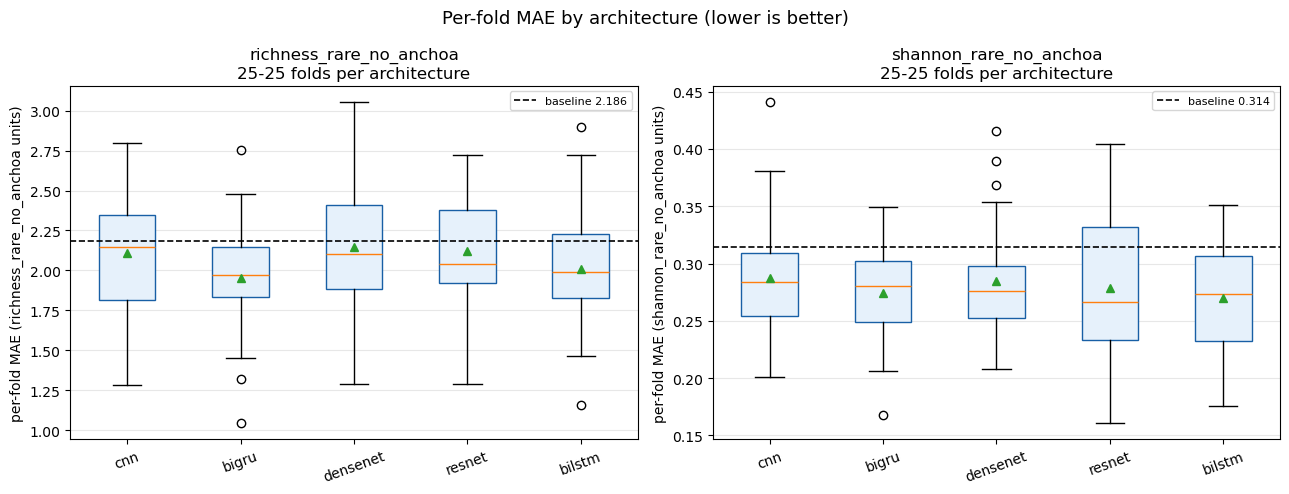

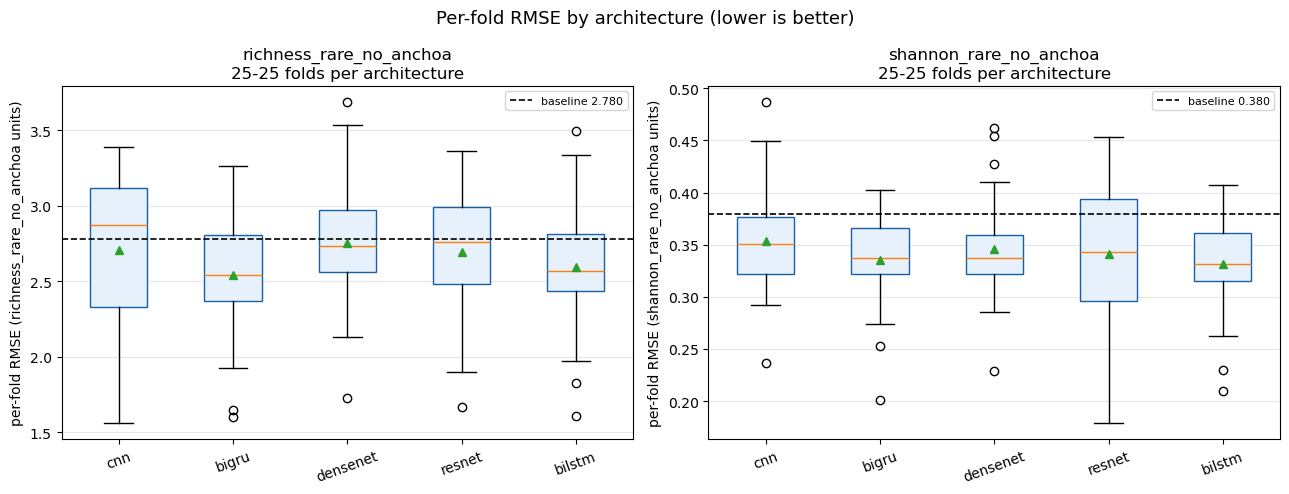

In [5]:

for metric, label in [("mae","MAE"), ("rmse","RMSE")]:
    fig, axes = plt.subplots(1, len(targets), figsize=(6.5*len(targets), 5), squeeze=False)
    for ax, tgt in zip(axes[0], targets):
        data, labs = [], []
        for m in models:
            v = FLr[(FLr["target"]==tgt) & (FLr["model"]==m)][metric].dropna().values
            if len(v): data.append(v); labs.append(m)
        if not data:
            ax.axis("off"); continue
        # tick labels set separately: matplotlib renamed boxplot's `labels` kwarg to
        # `tick_labels` in 3.9, so passing either one breaks on some versions
        bp = ax.boxplot(data, showmeans=True, patch_artist=True)
        ax.set_xticks(range(1, len(labs)+1)); ax.set_xticklabels(labs)
        for patch in bp["boxes"]:
            patch.set_facecolor("#E6F1FB"); patch.set_edgecolor("#185FA5")
        base_col = "MAE_median_base" if metric == "mae" else "RMSE_base"
        b = df[df["target"]==tgt][base_col].dropna()
        if len(b):
            ax.axhline(b.mean(), color="k", ls="--", lw=1.2, label=f"baseline {b.mean():.3f}")
            ax.legend(fontsize=8)
        ax.set_ylabel(f"per-fold {label} ({tgt} units)")
        ax.set_title(f"{tgt}\n{min(len(v) for v in data)}-{max(len(v) for v in data)} "
                     f"folds per architecture")
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=20)
    fig.suptitle(f"Per-fold {label} by architecture (lower is better)", fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"boxplot_fold_{metric}.png"), dpi=150, bbox_inches="tight")
    plt.show()


**Box plot — per-fold R².** Included because it is the metric everyone asks about, but note the boxes
are much wider than the MAE ones: R² is a ratio and each fold divides by its own spread.

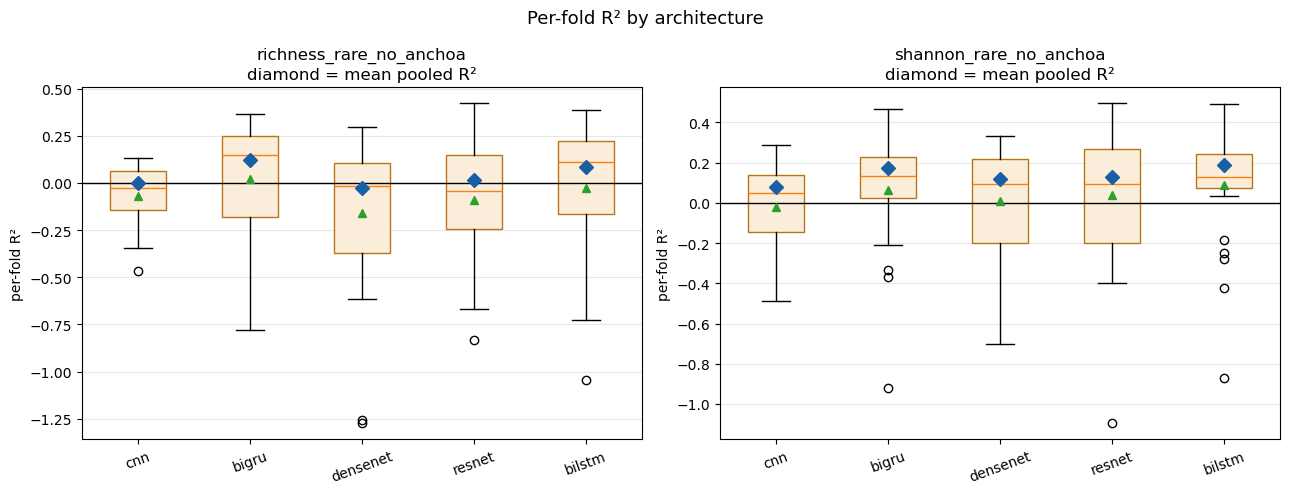

In [6]:

fig, axes = plt.subplots(1, len(targets), figsize=(6.5*len(targets), 5), squeeze=False)
for ax, tgt in zip(axes[0], targets):
    data, labs = [], []
    for m in models:
        v = FLr[(FLr["target"]==tgt) & (FLr["model"]==m)]["r2"].dropna()
        v = v[np.isfinite(v)].values
        if len(v): data.append(v); labs.append(m)
    if not data:
        ax.axis("off"); continue
    bp = ax.boxplot(data, showmeans=True, patch_artist=True)
    ax.set_xticks(range(1, len(labs)+1)); ax.set_xticklabels(labs)
    for patch in bp["boxes"]:
        patch.set_facecolor("#FAEEDA"); patch.set_edgecolor("#BA7517")
    ax.axhline(0, color="k", lw=1)
    # iterate over the plotted labels, which may omit models with no finite folds
    for x, m in enumerate(labs, start=1):
        p = df[(df["target"]==tgt) & (df["model"]==m)]["R2"].mean()
        if np.isfinite(p): ax.plot([x], [p], marker="D", ms=7, color="#185FA5", zorder=5)
    ax.set_ylabel("per-fold R²"); ax.set_title(f"{tgt}\ndiamond = mean pooled R²")
    ax.grid(axis="y", alpha=0.3); ax.tick_params(axis="x", rotation=20)
fig.suptitle("Per-fold R² by architecture", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "boxplot_fold_r2.png"), dpi=150, bbox_inches="tight")
plt.show()


**Early stopping.** A run whose folds mostly hit the epoch cap was still improving; one whose best
epoch is 1–2 everywhere is not learning past the mean.

In [7]:

es = df[["model","target","seed","folds","early_stopped","median_epochs","median_best_epoch"]].copy()
if es["early_stopped"].notna().any():
    agg = es.groupby(["target","model"]).agg(
        runs=("seed","count"), folds=("folds","sum"), early=("early_stopped","sum"),
        med_epochs=("median_epochs","median"), med_best=("median_best_epoch","median")).reset_index()
    agg["early_frac"] = (agg["early"] / agg["folds"]).map(lambda v: f"{v:.0%}")
    print(agg.to_string(index=False))
    capped = df[df["early_stopped"] < df["folds"]]
    if len(capped):
        print(f"\n{len(capped)} run(s) had folds reach the epoch cap -- consider raising EPOCHS.")
    else:
        print("\nEvery fold early-stopped; the epoch cap is not binding.")
else:
    print("No stopping information found.")

                 target    model  runs  folds  early  med_epochs  med_best early_frac
richness_rare_no_anchoa    bigru     5     25     25        24.0      14.0       100%
richness_rare_no_anchoa   bilstm     5     25     25        17.0       7.0       100%
richness_rare_no_anchoa      cnn     5     25     22        17.0       7.0        88%
richness_rare_no_anchoa densenet     5     25     24        20.0      10.0        96%
richness_rare_no_anchoa   resnet     5     25     24        18.0       8.0        96%
 shannon_rare_no_anchoa    bigru     5     25     24        17.0       7.0        96%
 shannon_rare_no_anchoa   bilstm     5     25     25        15.0       5.0       100%
 shannon_rare_no_anchoa      cnn     5     25     25        18.0       8.0       100%
 shannon_rare_no_anchoa densenet     5     25     25        19.0       9.0       100%
 shannon_rare_no_anchoa   resnet     5     25     24        20.0      10.0        96%

7 run(s) had folds reach the epoch cap -- consider ra